In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from scipy.stats import norm
from itertools import product
from typing import Dict, List, Set
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
from google.colab import files

## Synthetic Data Generation

In [ ]:
n_samples = 5000
K = 2          # clusters
M = 3          # modalities
d_m = 1        # 1D per modality
# Mixture Weights
p_y = np.array([0.5, 0.5])
# Fixed True Means
rng = np.random.default_rng(0)
true_means = {m: rng.normal(loc=0.0, scale=3.0, size=(K, d_m)) for m in range(M)}
# Shared Modalities Covariance
true_sigmas = {m: 0.5 + rng.random() for m in range(M)}

def sample_joint_continuous(N, p_y, means, sigmas, rng=None):
  if rng is None:
    rng = np.random.default_rng()
  K = len(p_y)
  M = len(means)
  Y = rng.choice(K, size=N, p=p_y)
  X = np.zeros((N, M))
  for i, y in enumerate(Y):
    for m in range(M):
      X[i, m] = rng.normal(loc=means[m][y, 0], scale=np.sqrt(sigmas[m]))
  return X, Y

X, Y = sample_joint_continuous(N=n_samples, p_y=p_y, means=true_means, sigmas=true_sigmas, rng=rng)

## Helper Functions

### Observed Vector

In [ ]:
def obs_vector(obs, M):
  x = np.zeros(M)
  for m, v in obs.items():
      x[m] = v
  return x

### Prediction using Observed Modalities

In [ ]:
def predict_from_obs(obs, p_y, means, sigmas):
  p_post = posterior_y(obs, p_y, means, sigmas)
  y_hat = np.argmax(p_post)
  loss = entropy(p_post)
  return y_hat, loss

### Label Matching

In [ ]:
def match_labels(y_true, y_pred, K):
  # Confusion matrix: rows = true labels, cols = predicted labels
  C = confusion_matrix(y_true, y_pred, labels=np.arange(K))
  # Hungarian algorithm (maximize total agreement)
  row_ind, col_ind = linear_sum_assignment(-C)
  # Build mapping: predicted -> true
  label_map = {pred: true for true, pred in zip(row_ind, col_ind)}
  # Apply mapping
  y_pred_matched = np.array([label_map[y] for y in y_pred])
  return y_pred_matched, label_map

### Entropy: $H(X)$

In [ ]:
def entropy(p, eps = 1e-12):
  p = np.clip(p, eps, 1.0)
  return -np.sum(p * np.log(p))

### Posterior: $p(Y|x^{(\mathcal{V})})$

In [ ]:
def posterior_y(obs, p_y, means, sigmas):
  logp = np.log(p_y + 1e-12)
  for v, x_v in obs.items():
    mu = means[v]          # shape: (K,)
    var = sigmas[v]
    logp += -0.5 * ((x_v - mu) ** 2) / var
    logp += -0.5 * np.log(2 * np.pi * var)
  logp -= np.max(logp)
  p = np.exp(logp)
  return p / p.sum()

### Conditional entropy: $H(Y|x^{(\mathcal{V})})$

In [ ]:
def conditional_entropy_y(obs, p_y, p_x_given_y):
  p_post = posterior_y(obs, p_y, p_x_given_y)
  return entropy(p_post)

### Plot Functions

In [ ]:
import matplotlib.pyplot as plt

def plot_ph1_loss_vs_Tph1(results):
  T_vals = [r["T_ph1"] for r in results]
  ph1_losses = [r["ph1_prediction_loss"] for r in results]

  plt.figure()
  plt.plot(T_vals, ph1_losses, marker='o')
  plt.xlabel(r"$T_{\mathrm{ph1}}$")
  plt.ylabel("Phase-1 Prediction Loss")
  plt.title("Phase-1 Loss vs Offline Initialization Length")
  plt.grid(True)
  plt.show()

def plot_ph2_loss_vs_Tph1(results):
  T_vals = [r["T_ph1"] for r in results]
  ph2_losses = [r["ph2_prediction_loss"] for r in results]

  plt.figure()
  plt.plot(T_vals, ph2_losses, marker='o')
  plt.xlabel(r"$T_{\mathrm{ph1}}$")
  plt.ylabel("Phase-2 Prediction Loss")
  plt.title("Phase-2 Loss vs Offline Initialization Length")
  plt.grid(True)
  plt.show()

def plot_total_loss_vs_Tph1(results, lambda_cost):
  T_vals = [r["T_ph1"] for r in results]
  total_losses = [r["total_prediction_loss"] for r in results]

  plt.figure()
  plt.plot(T_vals, total_losses, marker='o')
  plt.xlabel(r"$T_{\mathrm{ph1}}$")
  plt.ylabel("Total Prediction Loss")
  plt.title("Total Prediction Loss vs Offline Initialization Length")
  plt.grid(True)
  plt.ylim(0.1, 0.5) # Set y-axis limits
  filename = f"total_loss_plot_lmd{lambda_cost}.png"
  plt.savefig(filename, bbox_inches='tight', dpi=300)
  files.download(filename)
  plt.show()

## Acquisition with Learned Means

In [ ]:
def distortion_loss(obs, centers, p_post):
  x = obs_vector(obs, centers.shape[1])
  loss = 0.0
  for y, py in enumerate(p_post):
    loss += py * np.linalg.norm(x - centers[y]) ** 2
  return loss

In [ ]:
def Initialization_Phase(X, K):
  T_ph1, M = X.shape
  kmeans = KMeans(n_clusters=K, random_state=0)
  labels = kmeans.fit_predict(X)
  learned_centers = kmeans.cluster_centers_  # (K, M)
  # cluster prior
  p_y = np.bincount(labels, minlength=K) / T_ph1
  # per-modality variances (shared across clusters)
  learned_sigmas = {}
  learned_means = {}
  for v in range(M):
    learned_means[v] = learned_centers[:, v]
    learned_sigmas[v] = np.var(X[:, v]) + 1e-6
  return p_y, learned_means, learned_sigmas, learned_centers

In [ ]:
def expected_ig(v, obs, p_y, means, sigmas):
  """
  IG(Y; X_v | obs) computed using the learned joint
  """
  p_post = posterior_y(obs, p_y, means, sigmas)
  H_current = entropy(p_post)
  H_future = 0.0
  for y, py in enumerate(p_post):
    obs_new = dict(obs)
    obs_new[v] = means[v][y]  # conditional mean E[X^v|Y=y]
    p_post_future = posterior_y(obs_new, p_y, means, sigmas)
    H_future += py * entropy(p_post_future)
  return H_current - H_future

In [ ]:
def greedy_acquisition_policy(x_true, p_y, means, sigmas, lambda_cost, cost, budget,initial_obs=None, free_views=set()):
  M = len(means)
  observed = dict(initial_obs) if initial_obs is not None else {}
  V = set(observed.keys())
  spent = 0.0
  summary = []
  while True:
    gains = {}
    for v in range(M):
      #if v in V:
      if v in V or v in free_views:
        continue
      ig = expected_ig(v, observed, p_y, means, sigmas)
      gains[v] = ig - lambda_cost * cost
    if not gains:
      break
    v_star, best_gain = max(gains.items(), key=lambda x: x[1])
    if best_gain <= 0 or spent + cost > budget:
      break
    # acquire true value
    V.add(v_star)
    spent += cost
    observed[v_star] = x_true[v_star]
    budget = budget - spent
    summary.append({"chosen": v_star, "net_gain": best_gain, "V": set(V), "spent": spent})
  return observed, budget, summary


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.746, TotalLoss=0.326

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.738, TotalLoss=0.332

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.741, TotalLoss=0.340

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.744, TotalLoss=0.340

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.735, TotalLoss=0.342

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.725, TotalLoss=0.347

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.714, TotalLoss=0.353

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.705, TotalLoss=0.367

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.694, TotalLoss=0.376

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.681, TotalLoss=0.392

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.666, TotalLoss=0.409

Runn

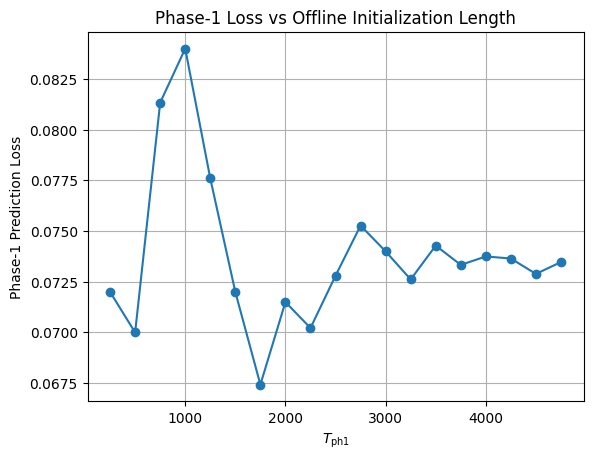

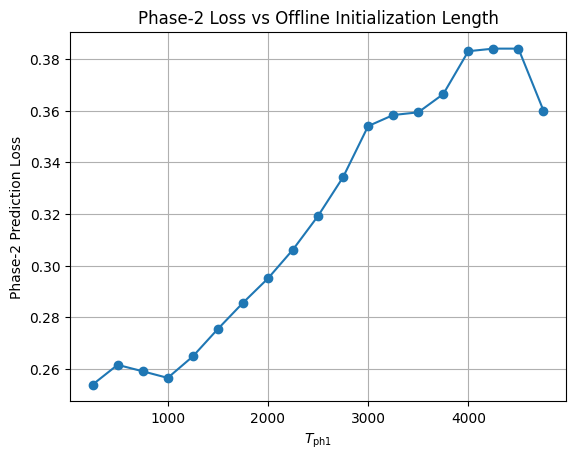

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

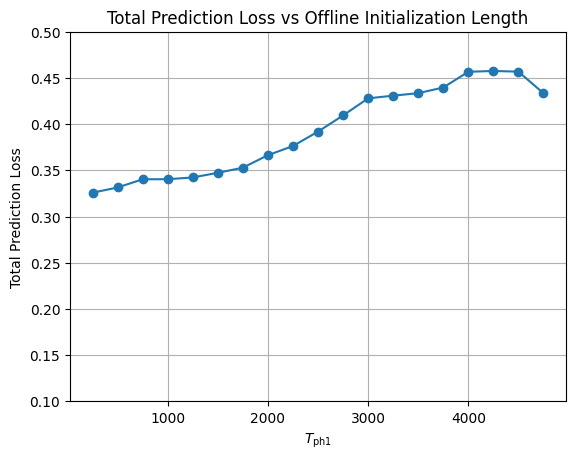


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.747, TotalLoss=0.325

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.739, TotalLoss=0.331

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.741, TotalLoss=0.340

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.744, TotalLoss=0.340

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.735, TotalLoss=0.342

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.725, TotalLoss=0.347

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.714, TotalLoss=0.353

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.705, TotalLoss=0.367

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.694, TotalLoss=0.376

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.681, TotalLoss=0.392

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.666, TotalLoss=0.409

Runn

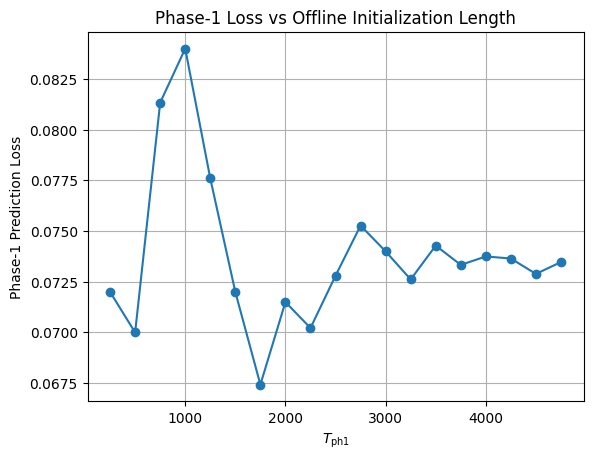

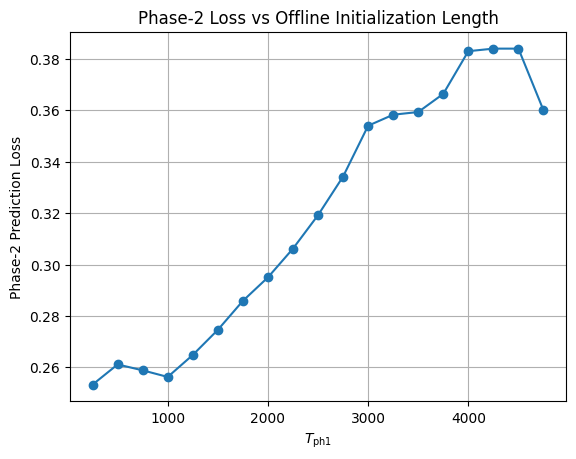

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

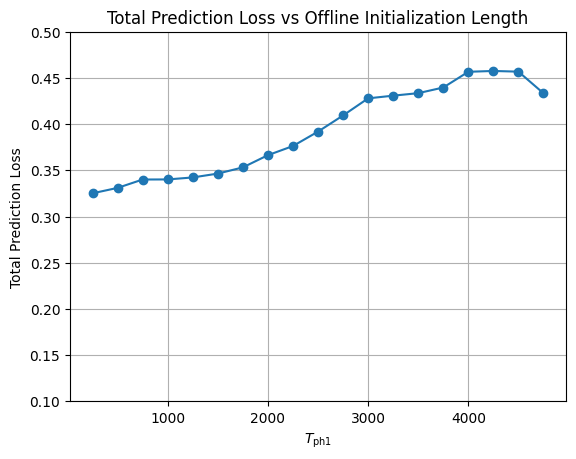


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.749, TotalLoss=0.323

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.740, TotalLoss=0.330

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.743, TotalLoss=0.339

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.745, TotalLoss=0.339

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.736, TotalLoss=0.341

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.727, TotalLoss=0.345

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.715, TotalLoss=0.352

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.706, TotalLoss=0.366

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.695, TotalLoss=0.375

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.682, TotalLoss=0.391

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.667, TotalLoss=0.409

Runn

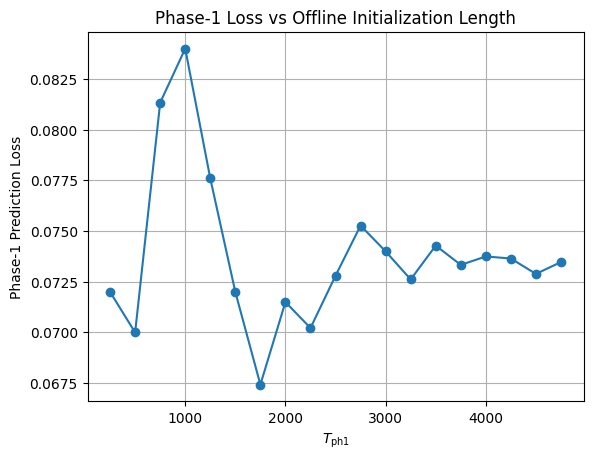

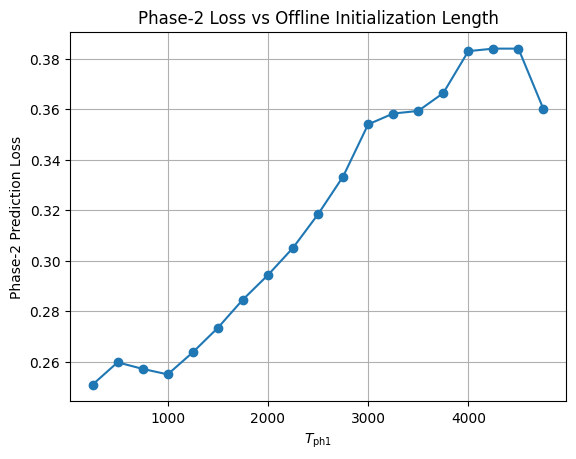

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

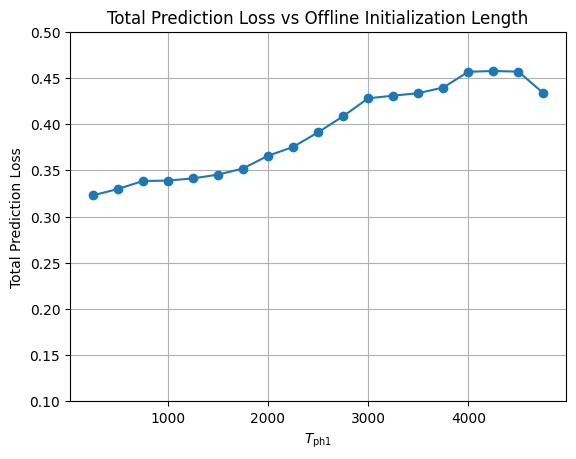


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.750, TotalLoss=0.322

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.744, TotalLoss=0.326

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.747, TotalLoss=0.335

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.747, TotalLoss=0.337

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.740, TotalLoss=0.338

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.728, TotalLoss=0.344

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.718, TotalLoss=0.350

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.707, TotalLoss=0.365

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.697, TotalLoss=0.373

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.682, TotalLoss=0.390

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.667, TotalLoss=0.408

Runn

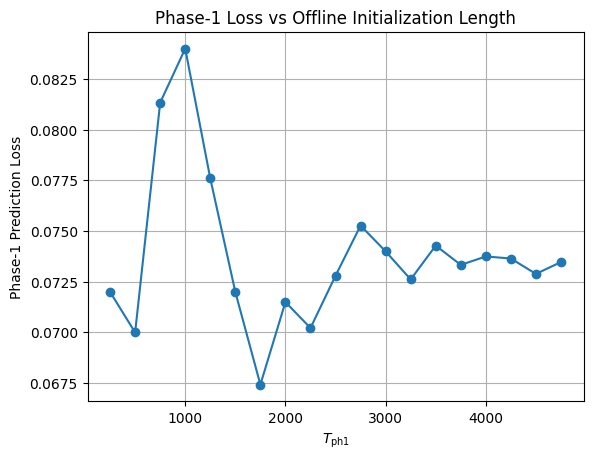

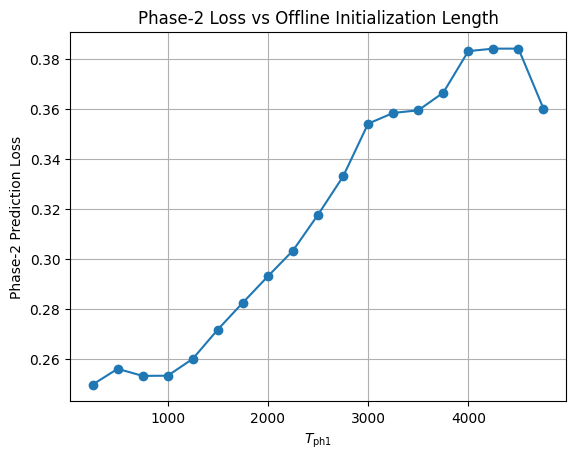

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

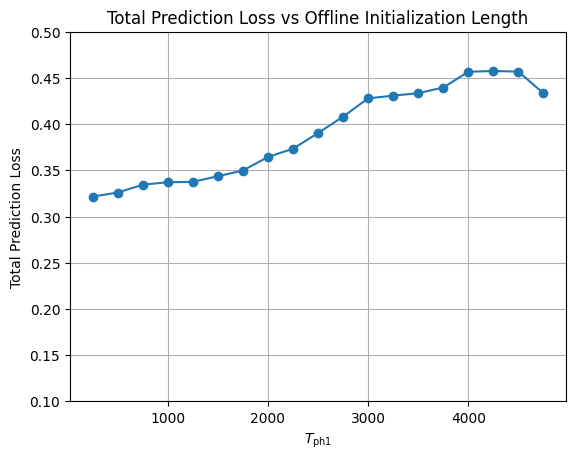


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.756, TotalLoss=0.316

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.750, TotalLoss=0.320

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.757, TotalLoss=0.324

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.756, TotalLoss=0.328

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.746, TotalLoss=0.332

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.734, TotalLoss=0.338

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.727, TotalLoss=0.340

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.716, TotalLoss=0.356

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.702, TotalLoss=0.368

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.685, TotalLoss=0.388

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.669, TotalLoss=0.406

Runn

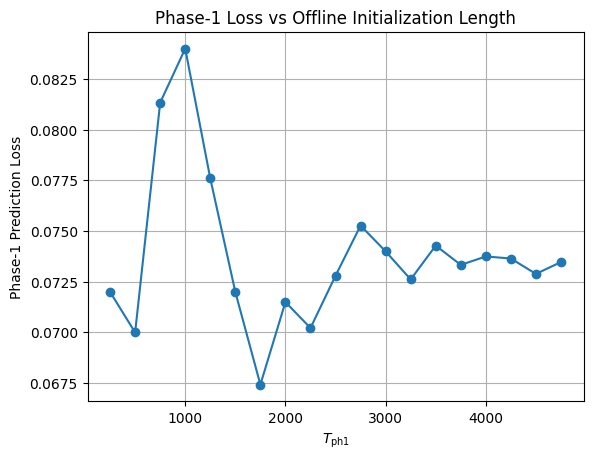

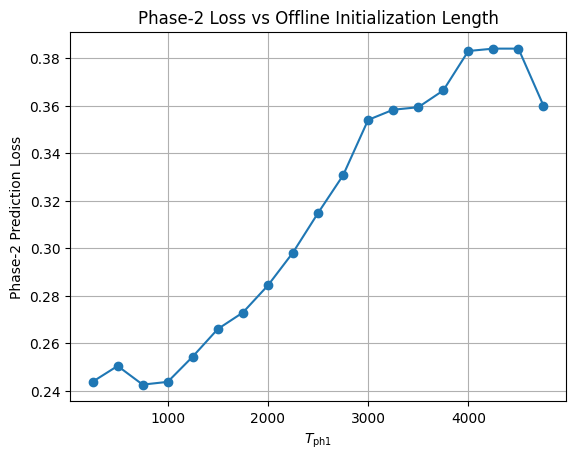

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

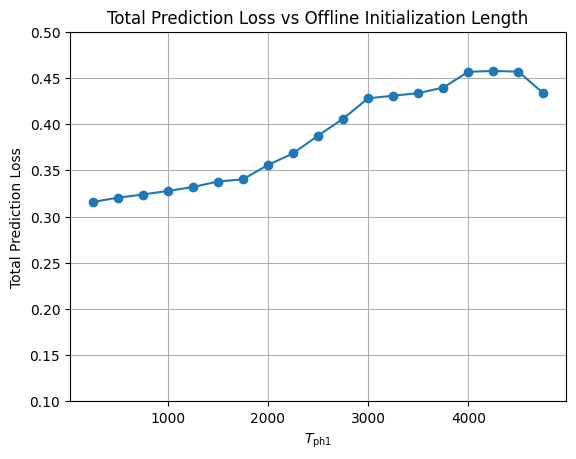


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.762, TotalLoss=0.310

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.773, TotalLoss=0.297

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.795, TotalLoss=0.287

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.795, TotalLoss=0.289

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.780, TotalLoss=0.298

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.761, TotalLoss=0.311

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.754, TotalLoss=0.313

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.740, TotalLoss=0.331

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.726, TotalLoss=0.344

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.703, TotalLoss=0.370

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.677, TotalLoss=0.398

Runn

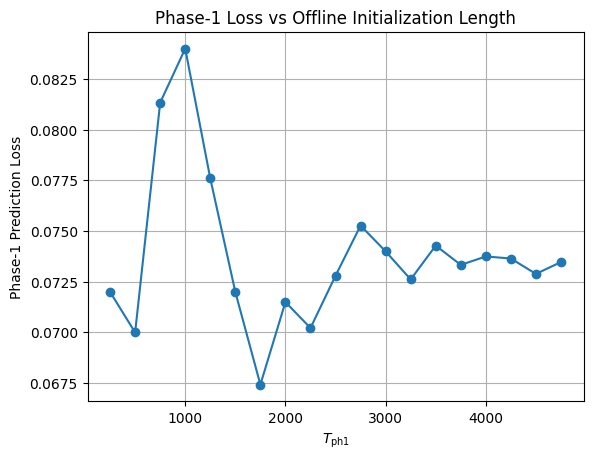

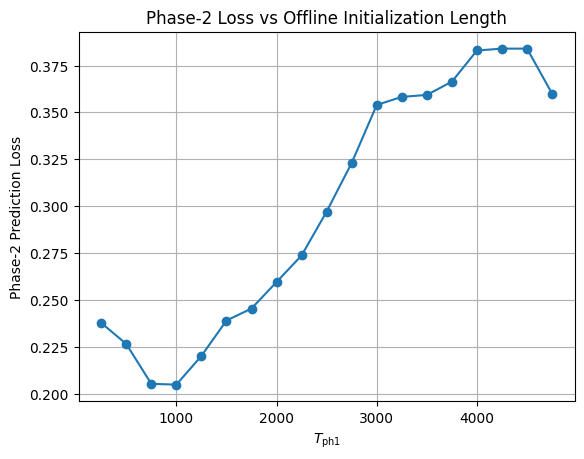

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

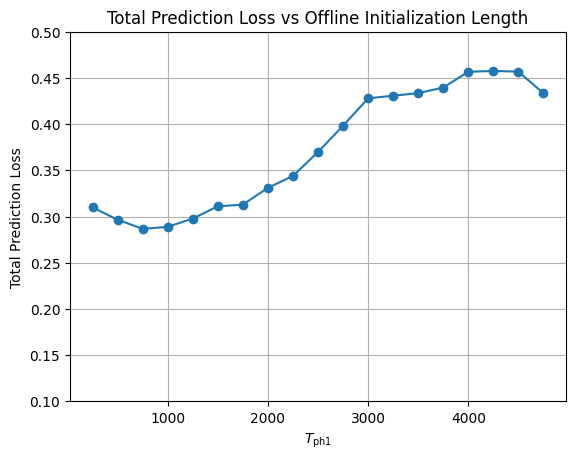


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.801, TotalLoss=0.271

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.884, TotalLoss=0.186

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.890, TotalLoss=0.191

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.904, TotalLoss=0.180

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.883, TotalLoss=0.194

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.860, TotalLoss=0.212

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.836, TotalLoss=0.231

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.809, TotalLoss=0.263

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.779, TotalLoss=0.292

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.741, TotalLoss=0.332

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.702, TotalLoss=0.373

Runn

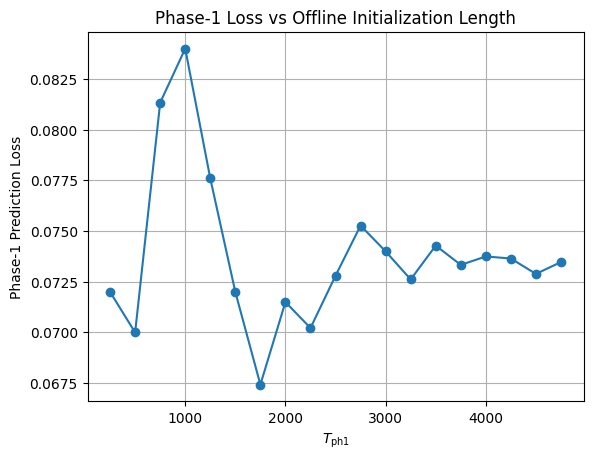

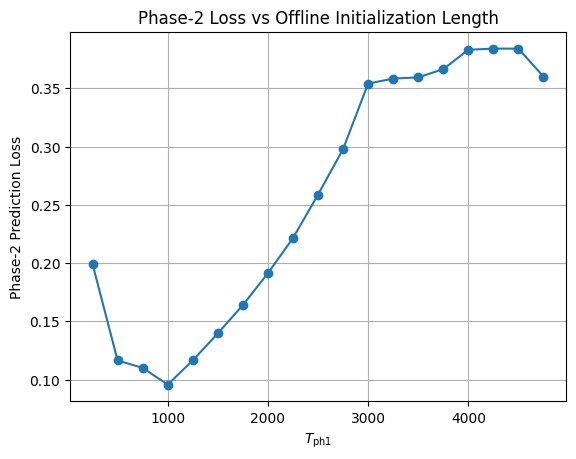

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

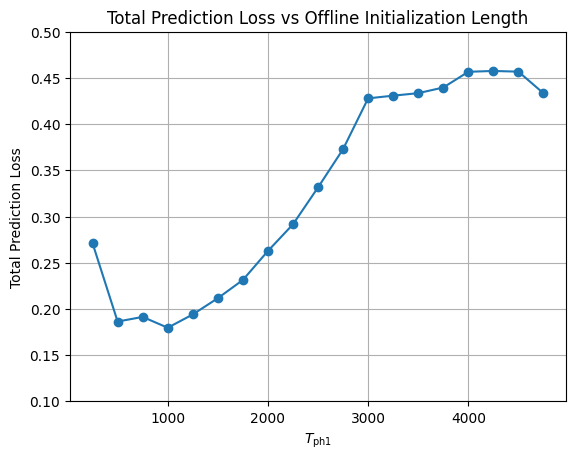


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.883, TotalLoss=0.189

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.884, TotalLoss=0.186

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.890, TotalLoss=0.191

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.904, TotalLoss=0.180

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.884, TotalLoss=0.194

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.861, TotalLoss=0.211

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.836, TotalLoss=0.231

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.809, TotalLoss=0.263

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.779, TotalLoss=0.292

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.741, TotalLoss=0.332

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.702, TotalLoss=0.373

Runn

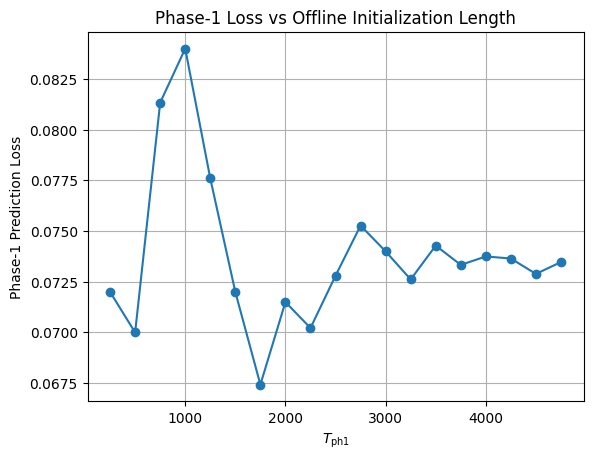

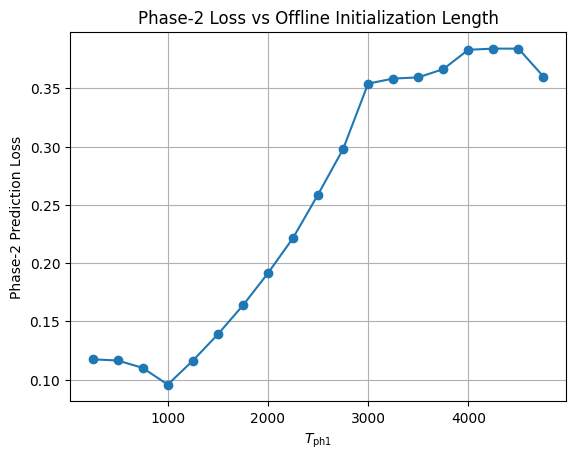

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

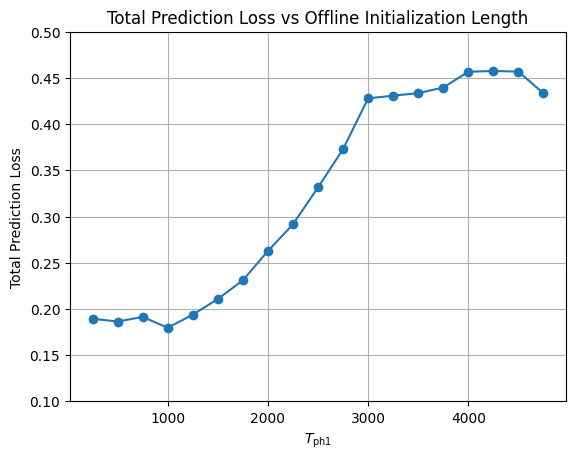


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.883, TotalLoss=0.189

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.884, TotalLoss=0.186

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.890, TotalLoss=0.191

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.904, TotalLoss=0.180

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.886, TotalLoss=0.191

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.865, TotalLoss=0.207

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.838, TotalLoss=0.229

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.810, TotalLoss=0.261

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.780, TotalLoss=0.290

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.742, TotalLoss=0.331

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.703, TotalLoss=0.373

Runn

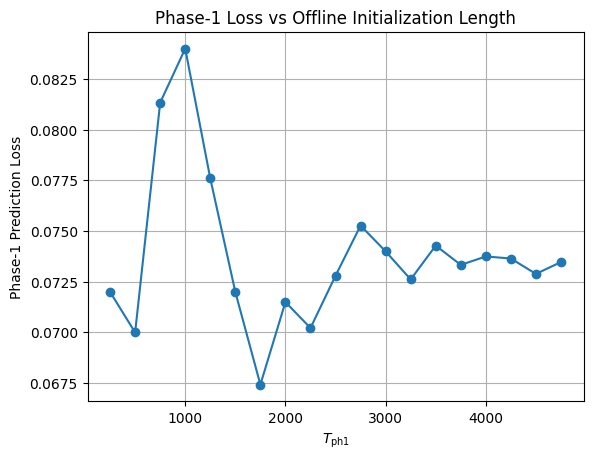

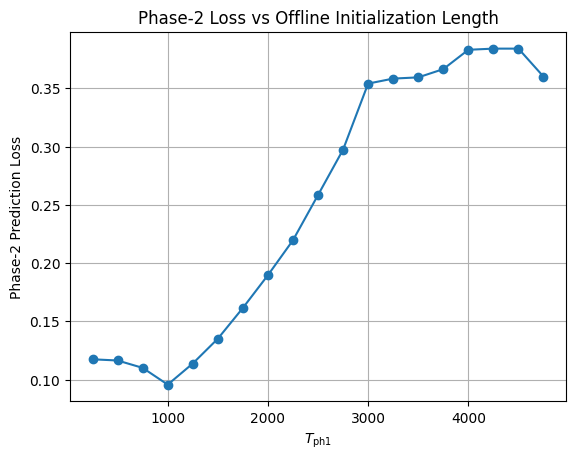

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

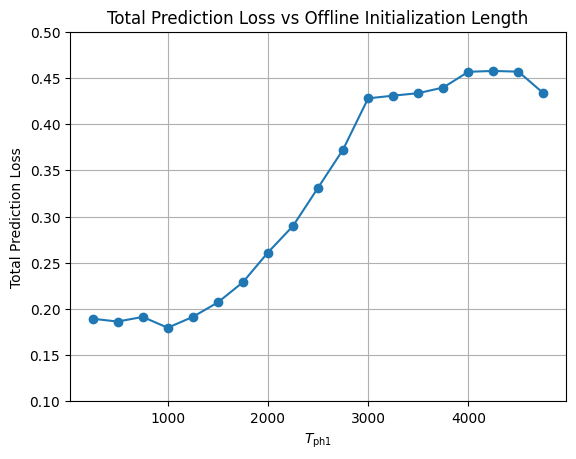


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.877, TotalLoss=0.195

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.881, TotalLoss=0.189

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.884, TotalLoss=0.197

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.733, TotalLoss=0.351

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.647, TotalLoss=0.430

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.644, TotalLoss=0.428

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.644, TotalLoss=0.423

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.642, TotalLoss=0.429

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.642, TotalLoss=0.428

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.642, TotalLoss=0.430

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.645, TotalLoss=0.430

Runn

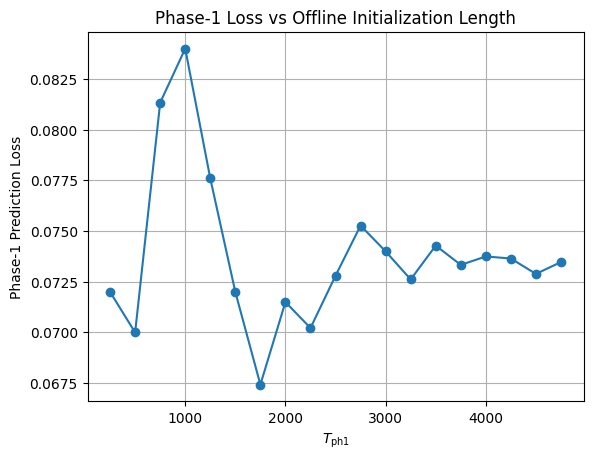

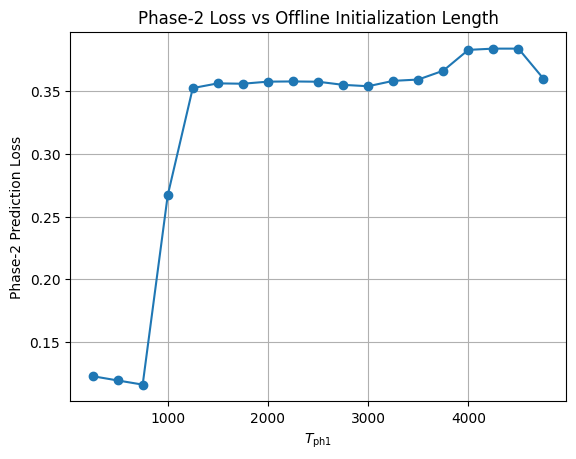

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

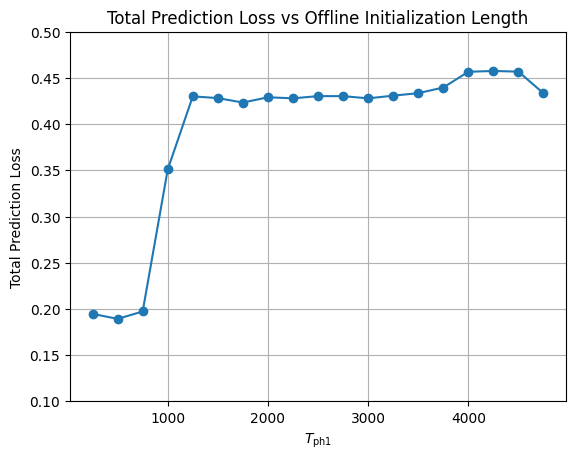


Running experiment with T_ph1 = 250
T_ph1=250 | Acc1=0.928, Acc2=0.640, TotalLoss=0.432

Running experiment with T_ph1 = 500
T_ph1=500 | Acc1=0.930, Acc2=0.637, TotalLoss=0.433

Running experiment with T_ph1 = 750
T_ph1=750 | Acc1=0.919, Acc2=0.640, TotalLoss=0.442

Running experiment with T_ph1 = 1000
T_ph1=1000 | Acc1=0.916, Acc2=0.646, TotalLoss=0.438

Running experiment with T_ph1 = 1250
T_ph1=1250 | Acc1=0.922, Acc2=0.647, TotalLoss=0.430

Running experiment with T_ph1 = 1500
T_ph1=1500 | Acc1=0.928, Acc2=0.644, TotalLoss=0.428

Running experiment with T_ph1 = 1750
T_ph1=1750 | Acc1=0.933, Acc2=0.644, TotalLoss=0.423

Running experiment with T_ph1 = 2000
T_ph1=2000 | Acc1=0.928, Acc2=0.642, TotalLoss=0.429

Running experiment with T_ph1 = 2250
T_ph1=2250 | Acc1=0.930, Acc2=0.642, TotalLoss=0.428

Running experiment with T_ph1 = 2500
T_ph1=2500 | Acc1=0.927, Acc2=0.642, TotalLoss=0.430

Running experiment with T_ph1 = 2750
T_ph1=2750 | Acc1=0.925, Acc2=0.645, TotalLoss=0.430

Runn

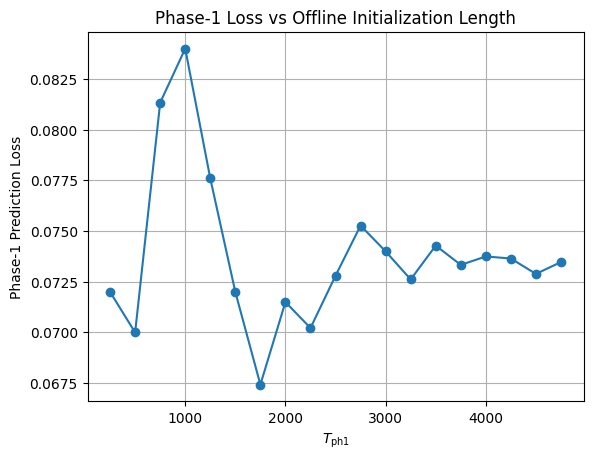

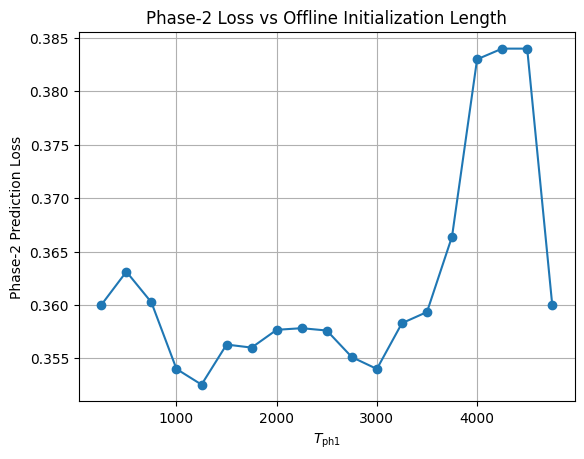

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

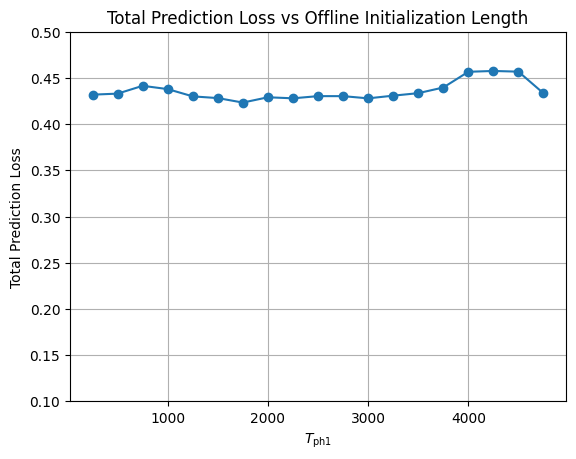

In [ ]:
FREE_VIEWS = {0}
Horizon = n_samples
cost = 1
T_ph1_list = list(range(250,Horizon,250))
for lambda_cost in np.arange(0.00, 0.21, 0.02):
  results = []
  for T_ph1 in T_ph1_list:
    print(f"\nRunning experiment with T_ph1 = {T_ph1}")
    # Global bookkeeping
    T_ph2 = Horizon - T_ph1
    Budget_total = Horizon * M * 0.4
    Budget_remaining = Budget_total - (T_ph1 * cost * (M - len(FREE_VIEWS)))

    # Phase 1: Initialization
    p_y, learned_means, learned_sigmas, learned_centers = Initialization_Phase(X[:T_ph1], K)
    y_pred_ph1 = []
    y_true_ph1 = []
    acc_ph1 = []
    post_loss_ph1 = []
    distortion_loss_ph1 = []
    for i in range(T_ph1):
      obs = {v: X[i, v] for v in range(M)}
      y_hat, post_loss = predict_from_obs(obs, p_y, learned_means, learned_sigmas)
      y_pred_ph1.append(y_hat)
      y_true_ph1.append(Y[i])
      post_loss_ph1.append(post_loss)
      p_post = posterior_y(obs, p_y, learned_means, learned_sigmas)
      distortion_loss_ph1.append(distortion_loss(obs, learned_centers, p_post))
    y_pred_ph1 = np.array(y_pred_ph1)
    y_true_ph1 = np.array(y_true_ph1)
    y_pred_ph1_matched, label_map = match_labels(y_true_ph1, y_pred_ph1, K)
    acc_ph1 = np.mean(y_pred_ph1_matched == y_true_ph1)

    # Phase 2: Inference
    y_pred_ph2 = []
    y_true_ph2 = []
    acc_ph2 = []
    post_loss_ph2 = []
    distortion_loss_ph2 = []
    histories = []
    for i in range(T_ph1, Horizon):
      initial_obs = {v: X[i, v] for v in FREE_VIEWS}
      obs, Budget_remaining, summary = greedy_acquisition_policy(x_true=X[i],p_y=p_y,means=learned_means,sigmas=learned_sigmas,lambda_cost=lambda_cost,cost=cost,budget=Budget_remaining,initial_obs=initial_obs,free_views=FREE_VIEWS)
      y_hat, post_loss = predict_from_obs(obs, p_y, learned_means, learned_sigmas)
      y_pred_ph2.append(y_hat)
      y_true_ph2.append(Y[i])
      post_loss_ph2.append(post_loss)
      histories.append(summary)
      p_post = posterior_y(obs, p_y, learned_means, learned_sigmas)
      distortion_loss_ph2.append(distortion_loss(obs, learned_centers, p_post))
    y_pred_ph2 = np.array(y_pred_ph2)
    y_true_ph2 = np.array(y_true_ph2)
    y_pred_ph2_matched, label_map = match_labels(y_true_ph2, y_pred_ph2, K)
    acc_ph2 = np.mean(y_pred_ph2_matched == y_true_ph2)
    # Aggregate metrics
    res = {
        "T_ph1": T_ph1,
        # Phase 1
        "acc_ph1": acc_ph1,
        "ph1_prediction_loss": 1 - acc_ph1,
        "post_loss_ph1": np.mean(post_loss_ph1),
        "dist_loss_ph1": np.mean(distortion_loss_ph1),
        # Phase 2
        "acc_ph2": acc_ph2,
        "ph2_prediction_loss": 1 - acc_ph2,
        "post_loss_ph2": np.mean(post_loss_ph2),
        "dist_loss_ph2": np.mean(distortion_loss_ph2),
        # Combined
        "total_prediction_loss":(1 - acc_ph1) + (1 - acc_ph2)
    }
    results.append(res)
    print(
        f"T_ph1={T_ph1} | "
        f"Acc1={res['acc_ph1']:.3f}, "
        f"Acc2={res['acc_ph2']:.3f}, "
        f"TotalLoss={res['total_prediction_loss']:.3f}"
    )

  plot_ph1_loss_vs_Tph1(results)
  plot_ph2_loss_vs_Tph1(results)
  plot_total_loss_vs_Tph1(results, lambda_cost)